In [16]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator, Aer
from qiskit.quantum_info import Statevector
from qiskit.circuit.library import MCXGate


from qiskit.visualization import plot_histogram
from qiskit.visualization import plot_distribution 

import numpy as np
from math import pi

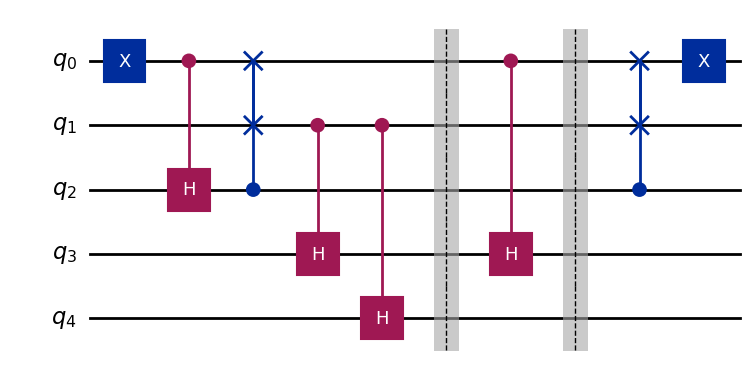

In [17]:
qc = QuantumCircuit(5)

#Working Memory 4 bits bit 0 no splitting, bit 1: spliting 1, bit 2: spliting two, bit 3 spliting 4

qc.x(0) #spliting to

#root
qc.ch(0,2)
#depth 1

qc.cswap(2,0,1)

qc.ch(1,3)
qc.ch(1,4)

qc.barrier()

qc.ch(0,3)

#undo withot h

qc.barrier()

qc.cswap(2,0,1)

qc.x(0)

qc.draw('mpl',fold=240)



Total count are: {np.str_('00000'): np.float64(0.25), np.str_('00100'): np.float64(0.125), np.str_('01000'): np.float64(0.25), np.str_('01100'): np.float64(0.125), np.str_('10100'): np.float64(0.125), np.str_('11100'): np.float64(0.125)}


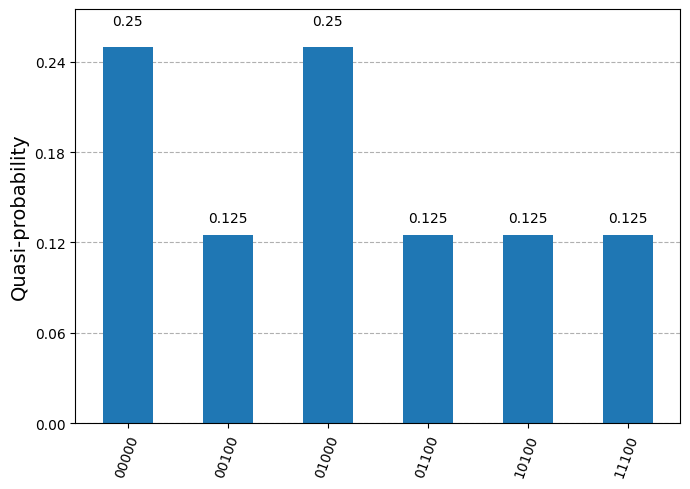

In [18]:
simulator = Aer.get_backend('statevector_simulator')
result=simulator.run(qc.decompose()).result()
counts = result.get_counts()
print("\nTotal count are:",counts)
plot_distribution(counts)